# 🧠 Predict BTC/ETH/SOL/XRP UPDOWN.

## 📌 Project Overview
- **Project Name**: precision_1h
- **Model Name**: UPDOWN
- **Author(s)**: reikano
- **Date**: 2025-07-21
- **Objective**: With high precision, predict whether the price will go up in the next 1-hour candle.
- **Use Case**: Primary application in Polymarket betting. Could potentially be used for trading on exchanges with low or no fees.
- **Model Type**: Binary classification (UP/DOWN), with regression sub-models possible.

---

## 🗃️ Dataset Description
- **Data Source(s)**: Binance Spot Market historical candle data (OHLCV).
- **Data Access**: Local CSV files exported via Binance API (or saved snapshots). 

### 📐 Features
| Feature Name                       | Description                                              | Type        | Notes                         |
|-----------------------------------|----------------------------------------------------------|-------------|-------------------------------|
| return                | Log return of previous candle                            | Numeric     |                |
| low/close                         | Ratio of low to close price                              | Numeric     | Candlestick ratio             |
| high/close                        | Ratio of high to close price                             | Numeric     | Candlestick ratio             |
| fisher_5                          | Fisher transform on 5-period data                        | Numeric     | Indicator                     |
| fisher_10                         | Fisher transform on 10-period data                       | Numeric     | Indicator                     |
| price_ratio_ema_X                 | Close/EMA(X) ratio for various periods (3, 5, 8, etc.)   | Numeric     | Trend features                |
| above_ema_X                       | Boolean: price above EMA(X)                              | Binary (0/1)| EMA 5, 10, 50, 100, 200       |
| hour_X                            | One-hot encoding for hour of day (0–23)                  | Binary      | Time context                  |
| weekday_X                         | One-hot encoding for weekday (0–6)                       | Binary      | Time context                  |

---

### 🎯 Target Variable
- **Type**: Binary classification target:  
  - `1` → price goes up in next candle  
  - `0` → price goes down or stays flat
- **Labeling Rule**: Based on whether the close price of the next candle is higher than the current one.

---

### 🔧 Preprocessing Steps
- **Missing Values**: Dropped any rows with nulls (e.g., from indicator lags)
- **Feature Scaling**:
  - Most features are ratio-based → already scale-invariant
  - But model trained with MinMax scaler.
- **Categorical Encoding**:
  - Hour and weekday as one-hot encoded binary columns

### 📊 Training
In training and testing I did use real life simulation. (Walk forward training)

- Train data
- Test
- Test data added to training data
- Train
- Test

Testing started from 2022:

- **Training**: 6 years of past data.
- **Test**: 230 candles.
- **Adjust**: Remove first 230 candles, add 230 test candles to dataset, rerun process.

- I have selected from 2022, because a bear market has started. I want to capture bear and bull markets in testing/training.
---

### 📊 Feature selection
I’ve kept the model with a minimal set of features because I wanted it to generalize well. With different feature selections, I’ve seen better results in terms of differentiating borderline 50/50 cases. However, at this stage my priority is to accurately predict high-probability bets, where a smaller set of features performs better. I selected the current features based on backtests that showed low drawdown. In some cases, other feature selections produced better results, but they also came with higher drawdowns, which I want to avoid for now.

---

### Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import scipy.stats as stats
import time
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from sklearn.metrics import (
    mean_squared_error,
    confusion_matrix,
    classification_report,
    r2_score,
    make_scorer,
    recall_score,
)
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import talib
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import label_binarize
import plotly.express as px
from sklearn.model_selection import TimeSeriesSplit
import ta
import talib
import warnings
warnings.filterwarnings('ignore')
import pandas_ta as p_ta


In [2]:
def fisher_transform(series, window=10):
    max_ = series.rolling(window).max()
    min_ = series.rolling(window).min()
    x = 2 * ((series - min_) / (max_ - min_) - 0.5)
    
    # Clip to avoid invalid log values
    x = x.clip(-0.999, 0.999)  # to keep values in valid range for log
    
    fisher = 0.5 * np.log((1 + x) / (1 - x))
    return fisher

import plotly.graph_objects as go

def build_trading_statistics(df_trades: pd.DataFrame):
    """Builds trading statistics overall, per year, and per month.

    Args:
        df_trades: DataFrame with 'log_return_target' and 'date' columns.

    Returns:
        DataFrame of statistics and plots of monthly win/loss.
    """
    # Ensure 'date' is datetime
    df_trades = df_trades.copy()
    df_trades['date'] = pd.to_datetime(df_trades['date'])

    # Add year and month columns
    df_trades['year'] = df_trades['date'].dt.year
    df_trades['month'] = df_trades['date'].dt.to_period('M')

    # Overall statistics
    def compute_stats(df):
        std_deviation = df['return_target'].std()
        max_return = df['return_target'].max()
        max_loss = df['return_target'].min()
        cumulative_return = df['return_target'].cumsum().iloc[-1]
        cumulative_max = df['return_target'].cumsum().cummax()
        drawdown = cumulative_max - df['return_target'].cumsum()
        max_drawdown = drawdown.max()

        streak = np.where(df['return_target'] > 0, 1, np.where(df['return_target'] < 0, -1, 0))
        streak_group = (pd.Series(streak) != pd.Series(streak).shift()).cumsum()
        streak_counts = pd.Series(streak).groupby(streak_group).sum()

        max_winning_streak = streak_counts[streak_counts > 0].max() if not streak_counts[streak_counts > 0].empty else 0
        max_losing_streak = -streak_counts[streak_counts < 0].min() if not streak_counts[streak_counts < 0].empty else 0
        win_rate = (df['return_target'] > 0).sum() / len(df) * 100
        total_trades = len(df)

        return pd.Series({
            'Total Trades': total_trades,
            'Standard Deviation': std_deviation,
            'Max Return': max_return,
            'Max Loss': max_loss,
            'Cumulative Return': cumulative_return,
            'Max Drawdown': max_drawdown,
            'Max Losing Streak': max_losing_streak,
            'Max Winning Streak': max_winning_streak,
            'Win Rate (%)': win_rate
        })

    overall_stats = compute_stats(df_trades).to_frame(name='Overall')
    yearly_stats = df_trades.groupby('year').apply(compute_stats).T
    monthly_stats = df_trades.groupby('month').apply(compute_stats).T

    # Monthly win/loss count plot using Plotly
    df_trades['win'] = df_trades['return_target'] > 0
    monthly_win_loss = df_trades.groupby('month')['win'].value_counts().unstack().fillna(0).sort_index()
    monthly_win_loss.columns = ['Losses', 'Wins']

    # Convert month index to string for better x-axis display
    month_str = monthly_win_loss.index.astype(str)

    fig = go.Figure(data=[
        go.Bar(name='Wins', x=month_str, y=monthly_win_loss['Wins']),
        go.Bar(name='Losses', x=month_str, y=monthly_win_loss['Losses'])
    ])

    fig.update_layout(
        barmode='stack',
        title='Monthly Win vs. Loss Count',
        xaxis_title='Month',
        yaxis_title='Number of Trades',
        legend_title='Result',
        height=500
    )

    fig.show()

    # Return all stats as a dictionary of DataFrames
    return {
        'Overall': overall_stats,
        'Yearly': yearly_stats,
        'Monthly': monthly_stats
    }
def plot_returns(df_plot: pd.DataFrame):
    """Build return plot.

        Args:
            df: dataframe, it needs to have log_return, date of trade.

        Returns:
            None
    """
    # Calculate cumulative returns
    df_plot.loc[:,'cumulative_return'] = (df_plot['return_target']).cumsum()
    
    # Plot cumulative returns
    plt.figure(figsize=(10, 5))
    plt.plot(df_plot['date'], df_plot['cumulative_return'], label='Cumulative Return', color='blue')
    
    # Labels and title
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.title("Cumulative returns for 4-hour candle returns when the model indicates UP, in bearish mode.")
    plt.legend()
    plt.grid()
    
    # Show plot
plt.show()

### Load data

In [3]:
symbol = "BTC"
df = pd.read_csv(f'{symbol}_1h_binance.csv')
df['date'] = pd.to_datetime(df['time'].astype(int),unit='ms')
df['return'] = (df['close'] - df['open']) / df['open']

### Build features

In [4]:
from scipy.stats import linregress
df['target'] = (df['return'].shift(-1) > 0.0).astype(int)
df['return_target'] = df['return'].shift(-1)
import numpy as np
import pandas as pd

df['low/close'] = df['low'] / df['close']
df['high/close'] = df['high'] / df['close']

# Fisher Transform (ensure you have this function defined)
df['fisher_5'] = fisher_transform(df['close'], window=5)
df['fisher_10'] = fisher_transform(df['close'], window=10)

# EMA Price Ratios
for span in [5, 8, 3, 10, 50, 100]:
    ema = df['close'].ewm(span=span, adjust=False).mean()
    df[f'price_ratio_ema_{span}'] = df['close'] / (ema)

# Interactions and combinations
df['price_ratio_ema_5_minus_high/close'] = df['price_ratio_ema_5'] - df['high/close']
df['price_ratio_ema_5_div_high/close'] = df['price_ratio_ema_5'] / (df['high/close'])
df['price_ratio_ema_5_minus_low/close'] = df['price_ratio_ema_5'] - df['low/close']
df['high/close_minus_price_ratio_ema_5'] = df['high/close'] - df['price_ratio_ema_5']
df['low/close_times_high/close_cos'] = (df['low/close'] * df['high/close']).apply(np.cos)
df['price_ratio_ema_5_minus_return'] = df['price_ratio_ema_5'] - df['return']
df['low/close_minus_price_ratio_ema_5'] = df['low/close'] - df['price_ratio_ema_5']
df['price_ratio_ema_10_minus_high/close'] = df['price_ratio_ema_10'] - df['high/close']
df['return_minus_low/close'] = df['return'] - df['low/close']
df['high/close_minus_price_ratio_ema_10'] = df['high/close'] - df['price_ratio_ema_10']
df['low/close_plus_high/close'] = df['low/close'] + df['high/close']
df['low/close_plus_high/close_sin'] = (df['low/close'] + df['high/close']).apply(np.sin)
df['fisher_5_div_return_cos'] = (df['fisher_5'] / (df['return'] + 1e-6)).apply(np.cos)
df['low/close_minus_price_ratio_ema_10_cos'] = (df['low/close'] - df['price_ratio_ema_10']).apply(np.cos)
df['low/close_times_high/close'] = df['low/close'] * df['high/close']
df['return_minus_price_ratio_ema_5'] = df['return'] - df['price_ratio_ema_5']
df['low/close_times_price_ratio_ema_5_cos'] = (df['low/close'] * df['price_ratio_ema_5']).apply(np.cos)


'''for i in [12, 24, 48, 200, 400, 1000]:
    df = add_realized_vol_feature_hourly(df=df,lookback_hours=i)'''
#hour = df['date'].dt.hour
#weekday = df['date'].dt.weekday  # 0=Monday, 1=Tuesday, ..., 6=Sunday

hour = df['date'].dt.hour
weekday = df['date'].dt.weekday  # 0=Monday, 1=Tuesday, ..., 6=Sunday

# Create dummy variables for hours and weekday
hour_dummies = pd.get_dummies(hour, prefix='hour', dtype=int)
weekday_dummies = pd.get_dummies(weekday, prefix='weekday', dtype=int)

df = pd.concat([df, hour_dummies, weekday_dummies], axis=1)

In [5]:
drop_features = [
                 'kli_close_time', 
                 'ignore', 'open',
                 'close','high',
                 'low','vol',
                 'quote_asset_val',
                 'num_trades', 
                 'taker_buy_base', 
                 'taker_buy_quote','time','coin','return','date',"return_target", 'target']


In [6]:
features_train = df.drop(drop_features,axis=1).columns.tolist()

In [7]:
features_train

['low/close',
 'high/close',
 'fisher_5',
 'fisher_10',
 'price_ratio_ema_5',
 'price_ratio_ema_8',
 'price_ratio_ema_3',
 'price_ratio_ema_10',
 'price_ratio_ema_50',
 'price_ratio_ema_100',
 'price_ratio_ema_5_minus_high/close',
 'price_ratio_ema_5_div_high/close',
 'price_ratio_ema_5_minus_low/close',
 'high/close_minus_price_ratio_ema_5',
 'low/close_times_high/close_cos',
 'price_ratio_ema_5_minus_return',
 'low/close_minus_price_ratio_ema_5',
 'price_ratio_ema_10_minus_high/close',
 'return_minus_low/close',
 'high/close_minus_price_ratio_ema_10',
 'low/close_plus_high/close',
 'low/close_plus_high/close_sin',
 'fisher_5_div_return_cos',
 'low/close_minus_price_ratio_ema_10_cos',
 'low/close_times_high/close',
 'return_minus_price_ratio_ema_5',
 'low/close_times_price_ratio_ema_5_cos',
 'hour_0',
 'hour_1',
 'hour_2',
 'hour_3',
 'hour_4',
 'hour_5',
 'hour_6',
 'hour_7',
 'hour_8',
 'hour_9',
 'hour_10',
 'hour_11',
 'hour_12',
 'hour_13',
 'hour_14',
 'hour_15',
 'hour_16',
 'h

### Run training

In [8]:
# Setup containers
models_predict = []
all_results = []
y_pred_list = []
y_test_list = []
probabilities_list = []
results = []

# Set up the LightGBM model
lgbm_model = LGBMClassifier(
    boosting_type='gbdt',
    colsample_bytree=1.0,
    importance_type='gain',
    learning_rate=0.01,
    max_depth=-1,
    min_child_samples=5,
    min_child_weight=0.001,
    n_estimators=300,
    num_leaves=31,
    subsample=1.0,
    verbose=-1
)

# Combine preprocessing and model into a pipeline
scaler = MinMaxScaler(feature_range=(0, 1))
lgbm_pipeline = Pipeline([
    ('scaler', scaler),
    ('lgbm', lgbm_model)
])

# Define time-series cross-validation
num_folds = 137
#num_folds = 30
test_size = 230
embargo_size = 0  # number of hours to wait after training before testing

tscv = TimeSeriesSplit(n_splits=num_folds, test_size=test_size)

# Prepare data
df['date_datetime'] = pd.to_datetime(df['date'])
if df['date_datetime'].dtype != 'datetime64[ns]':
    raise ValueError("Failed to convert 'date' column to datetime format")

# Define features to use in training (exclude target/date columns)
y = df['target']
X = df.copy()

# Walk-forward training loop with embargo
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    try:
        # --- Embargo logic ---
        embargo_start_time = X['date_datetime'].iloc[test_index[0]]
        embargo_end_time = embargo_start_time + pd.Timedelta(hours=embargo_size)

        # Limit training data to last 4 years
        cutoff_time = embargo_start_time - pd.Timedelta(hours=6 * 365.25 * 24)
        train_index = train_index[X['date_datetime'].iloc[train_index] >= cutoff_time]
        train_index = train_index[X['date_datetime'].iloc[train_index] < embargo_start_time]
        test_index = test_index[X['date_datetime'].iloc[test_index] >= embargo_end_time]

        # Skip fold if not enough data
        if len(train_index) == 0 or len(test_index) == 0:
            print(f"Skipping fold {fold} (train={len(train_index)}, test={len(test_index)}).")
            continue

        # Split data
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        print(f"Fold {fold}: Train {X_train['date_datetime'].min()} → {X_train['date_datetime'].max()}, "
              f"Test {X_test['date_datetime'].min()} → {X_test['date_datetime'].max()}")

        # Fit model
        model = lgbm_pipeline.fit(X_train[features_train], y_train)

        # Predict probabilities and labels
        y_pred_proba = model.predict_proba(X_test[features_train])[:, 1]
        threshold = 0.5
        y_pred = (y_pred_proba >= threshold).astype(int)

        # Evaluate
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)

        print(f"Recall: {recall:.2%} | Precision: {precision:.2%} | Accuracy: {accuracy:.2%}")

        # Save model
        model_name = f"{symbol}_1hour_{X_train.iloc[-1]['date']}.pkl"
        #joblib.dump(model, model_name)
        print(f"Model saved: {model_name}")

        # Collect results
        X_test = X_test.copy()
        X_test['y_pred_proba'] = y_pred_proba
        X_test['y_pred'] = y_pred
        X_test['true_label'] = y_test.values
        X_test['model_name'] = model_name
        results.append(X_test)

    except Exception as e:
        print(f"ERROR in fold {fold}: {e}")

Fold 0: Train 2017-08-17 04:00:00 → 2021-12-03 16:00:00, Test 2021-12-03 17:00:00 → 2021-12-13 06:00:00
Recall: 56.64% | Precision: 50.00% | Accuracy: 50.87%
Model saved: BTC_1hour_2021-12-03 16:00:00.pkl
Fold 1: Train 2017-08-17 04:00:00 → 2021-12-13 06:00:00, Test 2021-12-13 07:00:00 → 2021-12-22 19:00:00
Recall: 66.67% | Precision: 49.66% | Accuracy: 52.61%
Model saved: BTC_1hour_2021-12-13 06:00:00.pkl
Fold 2: Train 2017-08-17 04:00:00 → 2021-12-22 19:00:00, Test 2021-12-22 20:00:00 → 2022-01-01 09:00:00
Recall: 64.41% | Precision: 55.88% | Accuracy: 55.65%
Model saved: BTC_1hour_2021-12-22 19:00:00.pkl
Fold 3: Train 2017-08-17 04:00:00 → 2022-01-01 09:00:00, Test 2022-01-01 10:00:00 → 2022-01-10 23:00:00
Recall: 65.14% | Precision: 54.20% | Accuracy: 57.39%
Model saved: BTC_1hour_2022-01-01 09:00:00.pkl
Fold 4: Train 2017-08-17 04:00:00 → 2022-01-10 23:00:00, Test 2022-01-11 00:00:00 → 2022-01-20 13:00:00
Recall: 61.48% | Precision: 54.74% | Accuracy: 52.61%
Model saved: BTC_1hour

In [9]:
df_results = pd.concat(results)
# Assuming y_pred_proba is a column in the concatenated DataFrame 'results'
#df_results['return_target'] = np.log(df_results['close'].shift(-1) / df_results['open'].shift(-1))


In [10]:
recall = recall_score(df_results['true_label'], df_results['y_pred'])
        
print(f"Overall Recall: {recall * 100:.2f}%")
precision = precision_score(df_results['true_label'], df_results['y_pred'])
print(f"Overall Precision: {precision * 100:.2f}%")
      
from sklearn.metrics import accuracy_score
        
# Calculate accuracy
accuracy = accuracy_score(df_results['true_label'], df_results['y_pred'])
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

Overall Recall: 60.82%
Overall Precision: 54.92%
Overall Accuracy: 54.88%


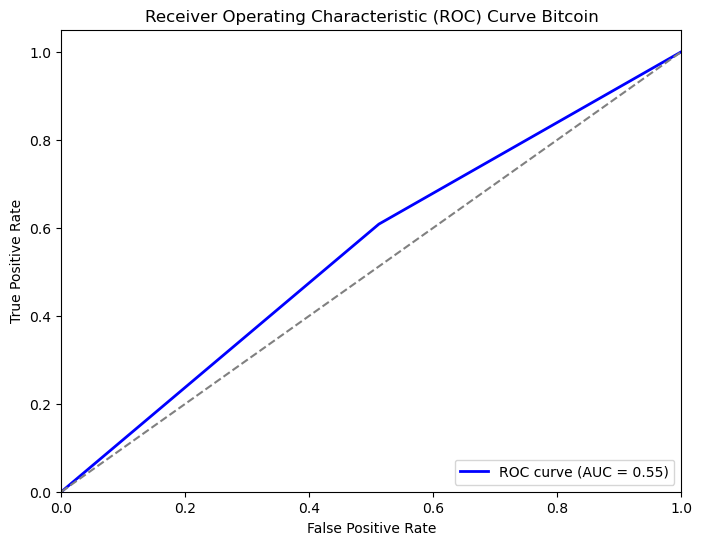

In [11]:
# Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(df_results['true_label'], df_results['y_pred'])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Bitcoin')
plt.legend(loc="lower right")
plt.show()

In [12]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Compute correctness
df_results['is_correct'] = df_results['y_pred'] == df_results['true_label']

# Filter range 0.3 to 0.76
df_filtered = df_results[(df_results['y_pred_proba'] >= 0.1) & (df_results['y_pred_proba'] <= 0.99)].copy()

# Bucket by 0.01
df_filtered['proba_bucket'] = pd.cut(df_filtered['y_pred_proba'], bins=np.arange(0.35, 0.75, 0.01), include_lowest=True)

# Group stats
bucket_stats = df_filtered.groupby('proba_bucket').agg(
    win_rate=('is_correct', 'mean'),
    correct_count=('is_correct', lambda x: (x == True).sum()),
    incorrect_count=('is_correct', lambda x: (x == False).sum())
).reset_index()

# Plot
fig = go.Figure()

fig.add_trace(go.Bar(
    x=bucket_stats['proba_bucket'].astype(str),
    y=bucket_stats['win_rate'],
    name='Win Rate',
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=bucket_stats['proba_bucket'].astype(str),
    y=bucket_stats['correct_count'],
    mode='lines+markers',
    name='Correct Count',
    yaxis='y2'
))

fig.add_trace(go.Scatter(
    x=bucket_stats['proba_bucket'].astype(str),
    y=bucket_stats['incorrect_count'],
    mode='lines+markers',
    name='Incorrect Count',
    yaxis='y2'
))

# Annotations for win rate
annotations = [
    dict(
        x=bucket_stats['proba_bucket'].astype(str).iloc[i],
        y=bucket_stats['win_rate'].iloc[i],
        text=f"{bucket_stats['win_rate'].iloc[i]:.2f}",
        showarrow=False,
        yanchor='bottom'
    ) for i in range(len(bucket_stats))
]

fig.update_layout(
    title='Win BTC Rate and Prediction Counts (Probability Bucket 0.3 to 0.76, step=0.01)',
    xaxis_title='Probability Bucket',
    yaxis=dict(
        title='Win Rate',
        tickformat=".0%",
        side='left',
        range=[0, 1]   # Force 0% to 100%
    ),
    yaxis2=dict(
        title='Count',
        overlaying='y',
        side='right'
    ),
    annotations=annotations,
    bargap=0.2,
    width=1250,
    height=800
)
fig.show()


We can evaluate how well each probability bucket performs in terms of prediction accuracy.  

**Example:**  
The bucket ranging from **0.57–0.58** in the backtest yielded a precision of **0.59**.  

In our case, we aim for the **highest possible precision**.  

In [13]:
threshold = 0.65

df_results["y_pred"] = ((df_results['y_pred_proba'] > threshold) & (df_results['y_pred_proba'] < 0.99))

In [14]:
threshold = 0.4

df_results["y_pred"] = ((df_results['y_pred_proba'] < threshold))

In [15]:
trading_statistics = build_trading_statistics( df_results.loc[df_results['y_pred']==1])

**Results win/losses by month each month in a backtest**

In [16]:
trading_statistics

{'Overall':                         Overall
 Total Trades        1687.000000
 Standard Deviation     0.005217
 Max Return             0.045845
 Max Loss              -0.030927
 Cumulative Return     -0.242845
 Max Drawdown           0.296571
 Max Losing Streak     11.000000
 Max Winning Streak     5.000000
 Win Rate (%)          39.478364,
 'Yearly': year                     2021        2022        2023        2024       2025
 Total Trades        47.000000  467.000000  572.000000  505.000000  96.000000
 Standard Deviation   0.005822    0.005768    0.004723    0.005321   0.004281
 Max Return           0.019770    0.045845    0.036829    0.034735   0.010069
 Max Loss            -0.010575   -0.018322   -0.018264   -0.030927  -0.024381
 Cumulative Return   -0.016595   -0.166667    0.038898   -0.038887  -0.059594
 Max Drawdown         0.047320    0.165186    0.149296    0.165896   0.079853
 Max Losing Streak    5.000000   10.000000   11.000000    9.000000  10.000000
 Max Winning Streak   4.

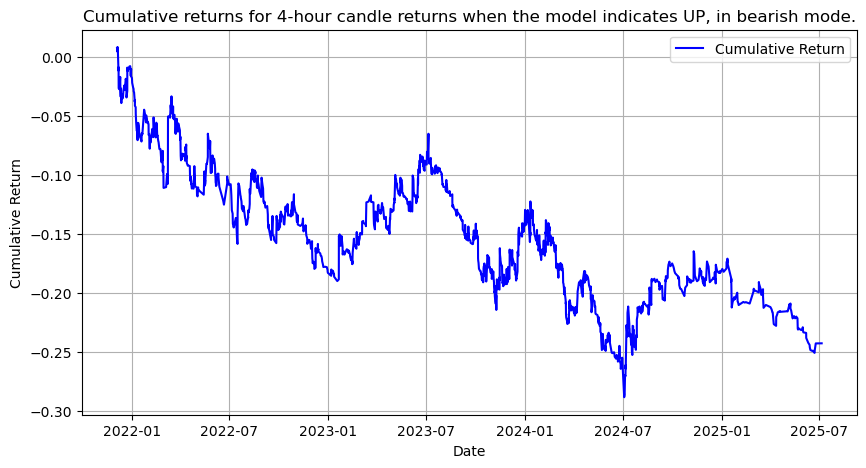

In [17]:
plot_returns(df_results.loc[df_results['y_pred']==1])

We choose fewer trades but with higher precision in order to minimize the number of losing months.  

**Backtest results:**  
- The only losing month was **2022-06**.  
- All other months achieved a win rate of **50% or higher**.  


### Shap values

In [18]:
import shap

# Ensure you have SHAP installed: pip install shap

#set the tree explainer as the model of the pipeline
explainer = shap.TreeExplainer(model['lgbm'])

#apply the preprocessing to x_test
observations = model['scaler'].transform(df_results[features_train])

#get Shap values from preprocessed data
shap_values = explainer.shap_values(observations)

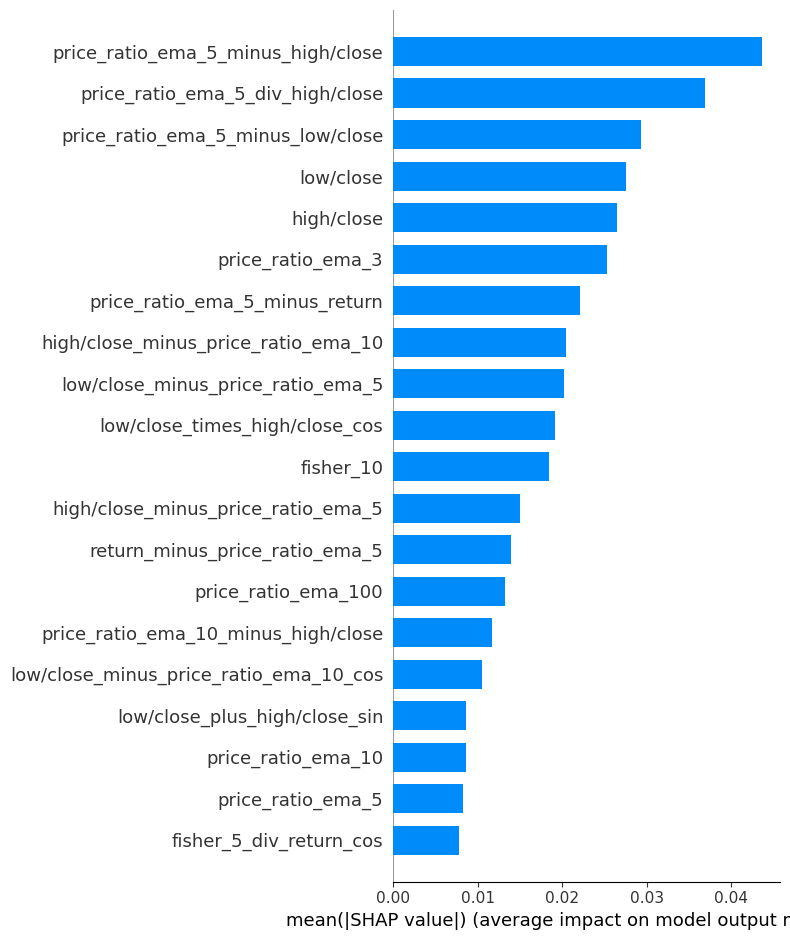

In [19]:
shap.summary_plot(shap_values, df_results[features_train], plot_type="bar")

### Conclusions:

- Simple features can yield high precision in predicting binary options, reaching over 60% win rate across ~2000 bets in 3–4 years.  
- The model consistently outperforms random UP/DOWN guessing, achieving nearly 55% accuracy compared to the ~51% baseline.  
- Predictions are market-dependent; during very unfavorable months for Bitcoin, losses may increase.  
- With the current feature selection, the most important feature is **price_ratio_ema_5**.  


In [20]:
# Run this BEFORE importing pyplot in the session
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

In [21]:
import pandas as pd
import numpy as np

def add_realized_vol_feature_hourly(
    df: pd.DataFrame,
    price_col: str = "close",
    lookback_hours: int = 6,
    feature_name: str | None = None,
) -> pd.DataFrame:
    """
    Compute realized volatility from hourly price data over the past `lookback_hours`.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with at least `price_col`.
    price_col : str
        Column containing prices.
    lookback_hours : int
        Rolling window length (in hours).
    feature_name : str
        Optional name for the new feature column.

    Returns
    -------
    pd.DataFrame
        Original dataframe with a new realized volatility column.
    """
    if feature_name is None:
        feature_name = f"rv_{lookback_hours}h"

    out = df.copy()

    # hourly log returns
    r = np.log(out[price_col]).diff()

    # realized variance = sum of squared returns over window
    realized_var = r.pow(2).rolling(window=lookback_hours).sum()

    # realized volatility = sqrt(realized variance), shifted to avoid lookahead
    out[feature_name] = np.sqrt(realized_var).shift(1)

    return out

In [22]:
for i in [12, 24, 48, 200, 400, 1000]:
    df = add_realized_vol_feature_hourly(df=df,lookback_hours=i)

In [23]:
df.columns

Index(['time', 'open', 'high', 'low', 'close', 'vol', 'kli_close_time',
       'quote_asset_val', 'num_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'coin', 'date', 'return', 'target', 'return_target',
       'low/close', 'high/close', 'fisher_5', 'fisher_10', 'price_ratio_ema_5',
       'price_ratio_ema_8', 'price_ratio_ema_3', 'price_ratio_ema_10',
       'price_ratio_ema_50', 'price_ratio_ema_100',
       'price_ratio_ema_5_minus_high/close',
       'price_ratio_ema_5_div_high/close', 'price_ratio_ema_5_minus_low/close',
       'high/close_minus_price_ratio_ema_5', 'low/close_times_high/close_cos',
       'price_ratio_ema_5_minus_return', 'low/close_minus_price_ratio_ema_5',
       'price_ratio_ema_10_minus_high/close', 'return_minus_low/close',
       'high/close_minus_price_ratio_ema_10', 'low/close_plus_high/close',
       'low/close_plus_high/close_sin', 'fisher_5_div_return_cos',
       'low/close_minus_price_ratio_ema_10_cos', 'low/close_times_high/close',
   

In [24]:
# --- EDA: rv_48 vs return_target ---------------------------------------------
import os
import math
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # safe for headless runs
import matplotlib.pyplot as plt

# Optional metrics (AUC/ROC) if available
try:
    from sklearn.metrics import roc_auc_score, roc_curve
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

# --- CONFIG -------------------------------------------------------------------
DF = df.copy()             # <--- your DataFrame
FEATURE = "rv_200h"
TARGET = "return_target"
OUTDIR = "eda_rv_48"

# --- PREP ---------------------------------------------------------------------
os.makedirs(OUTDIR, exist_ok=True)

DF = DF[[FEATURE, TARGET]].copy()
# Clean infs/nans
DF[FEATURE] = pd.to_numeric(DF[FEATURE], errors="coerce")
if DF[TARGET].dtype == "O":
    # try to map common labels like "UP"/"DOWN"
    DF[TARGET] = DF[TARGET].astype(str).str.strip().str.lower().replace({
        "up": 1, "down": 0, "rise": 1, "fall": 0, "true": 1, "false": 0
    })

DF.replace([np.inf, -np.inf], np.nan, inplace=True)
DF.dropna(subset=[FEATURE, TARGET], inplace=True)

n = len(df)
if n == 0:
    raise ValueError("No valid rows after cleaning. Check for NaNs or column names.")

# Detect target type
unique_vals = pd.unique(DF[TARGET])
is_binary_like = False
y_bin = None

# numeric?
if np.issubdtype(DF[TARGET].dtype, np.number):
    # try map {-1,1} to {0,1}
    if set(np.unique(DF[TARGET])).issubset({-1, 0, 1}):
        y = DF[TARGET].astype(float).values
        # map -1->0, keep 0/1 as-is
        y_bin = np.where(y == -1, 0, y)
        is_binary_like = set(np.unique(y_bin)).issubset({0, 1})
    elif DF[TARGET].nunique(dropna=True) <= 3 and set(np.unique(df[TARGET])).issubset({0,1}):
        y_bin = DF[TARGET].astype(int).values
        is_binary_like = True
    else:
        is_binary_like = False
else:
    # object/categorical after mapping earlier?
    if set(pd.unique(DF[TARGET])).issubset({0,1,"0","1"}):
        y_bin = DF[TARGET].astype(int).values
        is_binary_like = True

X = DF[FEATURE].values

# --- UNIVERSAL: distribution of rv_48 ----------------------------------------
plt.close("all")
plt.figure(figsize=(8, 5))
plt.hist(X, bins=50, density=True)
plt.xlabel(FEATURE)
plt.ylabel("Density")
plt.title(f"Distribution of {FEATURE} (n={n})")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "01_hist_rv_48.png"), dpi=300, bbox_inches="tight")
plt.close()

# --- BINARY TARGET EDA --------------------------------------------------------
summary_lines = []
summary_lines.append(f"Rows after cleaning: {n}")

if is_binary_like:
    y = y_bin.astype(int)

    # Basic group stats
    x_down = X[y == 0]
    x_up   = X[y == 1]
    def s(x): 
        return dict(n=len(x), mean=float(np.nanmean(x)), std=float(np.nanstd(x)))
    stats_down, stats_up = s(x_down), s(x_up)
    summary_lines.append(f"{FEATURE} | DOWN(0): {stats_down}")
    summary_lines.append(f"{FEATURE} | UP(1):   {stats_up}")

    # Cohen's d
    def cohens_d(a, b):
        n1, n2 = len(a), len(b)
        if n1 < 2 or n2 < 2:
            return float("nan")
        s1, s2 = np.var(a, ddof=1), np.var(b, ddof=1)
        sp = ((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2) if (n1+n2-2) > 0 else np.nan
        if sp <= 0 or np.isnan(sp): 
            return float("nan")
        return (np.mean(b) - np.mean(a)) / math.sqrt(sp)
    d = cohens_d(x_down, x_up)
    summary_lines.append(f"Cohen's d (UP vs DOWN): {d:.4f}")

    # Boxplot by class
    plt.figure(figsize=(7, 5))
    plt.boxplot([x_down, x_up], labels=["DOWN (0)", "UP (1)"], showfliers=False)
    plt.ylabel(FEATURE)
    plt.title(f"{FEATURE} by return_target")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "02_box_by_class.png"), dpi=300, bbox_inches="tight")
    plt.close()

    # Histograms by class (separate panels to avoid overlap confusion)
    for cls, arr in [(0, x_down), (1, x_up)]:
        plt.figure(figsize=(8, 5))
        plt.hist(arr, bins=50, density=True)
        plt.xlabel(FEATURE)
        plt.ylabel("Density")
        plt.title(f"Distribution of {FEATURE} | return_target={cls} (n={len(arr)})")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"03_hist_by_class_{cls}.png"), dpi=300, bbox_inches="tight")
        plt.close()

    # Binned probability of UP by rv_48 quantiles
    q = np.linspace(0, 1, 11)
    cuts = np.quantile(X, q)
    # guard against duplicate cut points
    cuts = np.unique(cuts)
    if len(cuts) >= 3:
        labels = [f"Q{i+1}" for i in range(len(cuts)-1)]
        bin_idx = np.digitize(X, bins=cuts[1:-1], right=True)
        prob_up = pd.Series(y).groupby(bin_idx).mean()
        centers = []
        for i in range(len(cuts)-1):
            centers.append((cuts[i] + cuts[i+1]) / 2)
        centers = np.array(centers[:len(prob_up)])

        plt.figure(figsize=(8, 5))
        plt.plot(centers, prob_up.values, marker="o")
        plt.xlabel(FEATURE)
        plt.ylabel("P(UP | bin)")
        plt.title(f"P(UP) across {FEATURE} quantile bins")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "04_prob_up_by_quantile.png"), dpi=300, bbox_inches="tight")
        plt.close()

        # also save as bar chart by bin index (for quick glance)
        plt.figure(figsize=(8, 5))
        plt.bar(range(len(prob_up)), prob_up.values)
        plt.xticks(range(len(prob_up)), [f"Q{i+1}" for i in range(len(prob_up))], rotation=0)
        plt.ylabel("P(UP)")
        plt.title(f"P(UP) by {FEATURE} quantiles")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "05_prob_up_by_quantile_bar.png"), dpi=300, bbox_inches="tight")
        plt.close()

    # ROC / AUC using rv_48 as a single score
    if SKLEARN_OK and len(np.unique(y)) == 2:
        try:
            auc_forward = roc_auc_score(y, X)
            auc_reverse = roc_auc_score(y, -X)
            if auc_reverse > auc_forward:
                score = -X
                auc = auc_reverse
                direction = "higher rv_48 → DOWN"
            else:
                score = X
                auc = auc_forward
                direction = "higher rv_48 → UP"

            fpr, tpr, _ = roc_curve(y, score)
            plt.figure(figsize=(6, 6))
            plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
            plt.plot([0, 1], [0, 1], linestyle="--")
            plt.xlabel("FPR")
            plt.ylabel("TPR")
            plt.title(f"ROC using {FEATURE} only\n(Direction: {direction})")
            plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(OUTDIR, "06_roc_single_feature.png"), dpi=300, bbox_inches="tight")
            plt.close()

            summary_lines.append(f"AUC (best orientation): {auc:.4f} | {direction}")
        except Exception as e:
            summary_lines.append(f"ROC/AUC failed: {e}")

    # Correlation with binary target (point-biserial ~ Pearson with 0/1)
    try:
        corr = np.corrcoef(X, y)[0,1]
        summary_lines.append(f"Pearson corr({FEATURE}, UP[0/1]): {corr:.4f}")
    except Exception as e:
        summary_lines.append(f"Correlation failed: {e}")

# --- CONTINUOUS TARGET EDA ----------------------------------------------------
else:
    y = pd.to_numeric(df[TARGET], errors="coerce").values
    m = np.isfinite(y) & np.isfinite(X)
    X, y = X[m], y[m]
    n2 = len(X)
    summary_lines.append(f"Target treated as continuous (n={n2})")

    # Scatter
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, s=8, alpha=0.6)
    plt.xlabel(FEATURE)
    plt.ylabel(TARGET)
    plt.title(f"{TARGET} vs {FEATURE}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "02_scatter_continuous.png"), dpi=300, bbox_inches="tight")
    plt.close()

    # Correlations
    try:
        pear = np.corrcoef(X, y)[0,1]
        summary_lines.append(f"Pearson corr({FEATURE}, {TARGET}): {pear:.4f}")
    except Exception as e:
        summary_lines.append(f"Pearson failed: {e}")
    print(summary_lines)
    # Binned average target by feature quantiles
    q = np.linspace(0, 1, 11)
    cuts = np.quantile(X, q)
    cuts = np.unique(cuts)
    if len(cuts) >= 3:
        bin_idx = np.digitize(X, bins=cuts[1:-1], right=True)
        mean_y = pd.Series(y).groupby(bin_idx).mean()
        centers = []
        for i in range(len(cuts)-1):
            centers.append((cuts[i] + cuts[i+1]) / 2)
        centers = np.array(centers[:len(mean_y)])

        plt.figure(figsize=(8, 5))
        plt.plot(centers, mean_y.values, marker="o")
        plt.xlabel(FEATURE)
        plt.ylabel(f"Mean({TARGET})")
        plt.title(f"Mean {TARGET} across {FEATURE} quantile bins")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "03_mean_target_by_quantile.png"), dpi=300, bbox_inches="tight")
        plt.close()

# --- WRITE SUMMARY ------------------------------------------------------------
with open(os.path.join(OUTDIR, "00_summary.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("EDA complete. Files saved in:", OUTDIR)
for fname in sorted(os.listdir(OUTDIR)):
    print(" -", fname)


ValueError: operands could not be broadcast together with shapes (69089,) (68887,) 